# STABILIS — Customer Purchase Propensity Modeling

## Stage 2: Machine Learning

Objective:
Predict whether a customer will make a purchase during a future observation period using only information available before the prediction period.

## 2.1 Define the ML Business Problem

Business Question:
Which customers are likely to make a purchase in a future period?

Target:
PurchaseInFuture

1 = customer makes at least one future purchase
0 = customer makes no future purchase

The final PurchaseProbability will be generated from the trained ML model's predict_proba() output.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel("../Data/Customers_Transactions.xlsx")

df["EventDateTime"] = pd.to_datetime(df["EventDateTime"])

# Remove exact duplicate rows identified during Stage 1
df = df.drop_duplicates().copy()

print("Rows:", len(df))
print("Minimum date:", df["EventDateTime"].min())
print("Maximum date:", df["EventDateTime"].max())

Rows: 410763
Minimum date: 2019-12-01 07:45:00
Maximum date: 2020-12-09 20:01:00


## 2.2 Temporal Prediction Setup

The prediction cutoff is defined as 90 days before the final transaction date.

Customer features will be calculated using transactions available on or before the cutoff.

The target variable, PurchaseInFuture, indicates whether the customer makes at least one purchase during the following 90-day period.

In [3]:
# Define prediction cutoff
max_date = df["EventDateTime"].max()

cutoff_date = max_date - pd.Timedelta(days=90)

print("Maximum date:", max_date)
print("Prediction cutoff:", cutoff_date)
print("Future window ends:", max_date)

Maximum date: 2020-12-09 20:01:00
Prediction cutoff: 2020-09-10 20:01:00
Future window ends: 2020-12-09 20:01:00


In [4]:
# Historical period: information available for feature creation
historical_df = df[
    df["EventDateTime"] <= cutoff_date
].copy()

# Future period: used only to create the prediction target
future_df = df[
    (df["EventDateTime"] > cutoff_date) &
    (df["EventDateTime"] <= max_date)
].copy()

print("Historical rows:", len(historical_df))
print("Future rows:", len(future_df))

Historical rows: 260364
Future rows: 150399


In [5]:
future_purchases = (
    future_df[future_df["EventType"] == "Purchased"]
    .groupby("UserID")
    .size()
    .rename("FuturePurchaseCount")
)

print("Customers with future purchases:", len(future_purchases))

Customers with future purchases: 2877


In [6]:
# Customers present in the historical period
customer_base = pd.DataFrame({
    "UserID": historical_df["UserID"].unique()
})

customer_base = customer_base.merge(
    future_purchases,
    on="UserID",
    how="left"
)

customer_base["FuturePurchaseCount"] = (
    customer_base["FuturePurchaseCount"]
    .fillna(0)
)

customer_base["PurchaseInFuture"] = (
    customer_base["FuturePurchaseCount"] > 0
).astype(int)

print(customer_base["PurchaseInFuture"].value_counts())

PurchaseInFuture
1    1956
0    1493
Name: count, dtype: int64


## 2.3 Historical Customer Features

Customer features are calculated using only transactions available on or before the prediction cutoff.

Features include purchase frequency, gross revenue, average basket value, recency, product breadth, and return behavior.

No information from the future prediction window is used in feature creation.

In [7]:
# Create line value from transaction-level data
historical_df["LineValue"] = (
    historical_df["Quantity"] * historical_df["UnitPrice"]
)

# Separate purchases and returns
historical_purchases = historical_df[
    historical_df["EventType"] == "Purchased"
].copy()

historical_returns = historical_df[
    historical_df["EventType"] == "Returned"
].copy()

In [8]:
purchase_features = (
    historical_purchases
    .groupby("UserID")
    .agg(
        PurchaseFrequency=("EventID", "nunique"),
        GrossRevenue=("LineValue", "sum"),
        UniqueProducts=("ProductID", "nunique"),
        LastPurchaseDate=("EventDateTime", "max")
    )
    .reset_index()
)

purchase_features["AverageBasketValue"] = (
    purchase_features["GrossRevenue"]
    / purchase_features["PurchaseFrequency"]
)

purchase_features["RecencyDays"] = (
    cutoff_date - purchase_features["LastPurchaseDate"]
).dt.total_seconds() / (24 * 60 * 60)

In [9]:
return_features = (
    historical_returns
    .groupby("UserID")
    .agg(
        ReturnEvents=("EventID", "nunique"),
        ReturnValue=("LineValue", lambda x: x.abs().sum())
    )
    .reset_index()
)

In [10]:
model_df = customer_base.merge(
    purchase_features,
    on="UserID",
    how="left"
)

model_df = model_df.merge(
    return_features,
    on="UserID",
    how="left"
)

model_df["ReturnEvents"] = model_df["ReturnEvents"].fillna(0)
model_df["ReturnValue"] = model_df["ReturnValue"].fillna(0)

In [11]:
model_df["ReturnValueRate"] = np.where(
    model_df["GrossRevenue"] > 0,
    model_df["ReturnValue"] / model_df["GrossRevenue"],
    0
)

In [12]:
print(model_df.shape)
print(model_df.isna().sum())
print(model_df.head())

(3449, 12)
UserID                  0
FuturePurchaseCount     0
PurchaseInFuture        0
PurchaseFrequency      70
GrossRevenue           70
UniqueProducts         70
LastPurchaseDate       70
AverageBasketValue     70
RecencyDays            70
ReturnEvents            0
ReturnValue             0
ReturnValueRate         0
dtype: int64
   UserID  FuturePurchaseCount  PurchaseInFuture  PurchaseFrequency  \
0   25430                  0.0                 0                6.0   
1   25423                140.0                 1               24.0   
2   27707                 17.0                 1                1.0   
3   30447                 60.0                 1               78.0   
4   25027                153.0                 1               16.0   

   GrossRevenue  UniqueProducts    LastPurchaseDate  AverageBasketValue  \
0     471636.60            33.0 2020-01-29 11:42:00        78606.100000   
1    2578722.68            83.0 2020-09-03 14:28:00       107446.778333   
2     112372

In [13]:
# Customers with no historical purchase record
purchase_feature_cols = [
    "PurchaseFrequency",
    "GrossRevenue",
    "UniqueProducts",
    "AverageBasketValue",
    "RecencyDays"
]

model_df[purchase_feature_cols] = (
    model_df[purchase_feature_cols].fillna(0)
)

In [14]:
model_df["NoPurchaseHistory"] = (
    model_df["PurchaseFrequency"] == 0
).astype(int)

In [15]:
print(model_df[purchase_feature_cols + ["NoPurchaseHistory"]].isna().sum())

print(
    model_df["NoPurchaseHistory"].value_counts()
)

PurchaseFrequency     0
GrossRevenue          0
UniqueProducts        0
AverageBasketValue    0
RecencyDays           0
NoPurchaseHistory     0
dtype: int64
NoPurchaseHistory
0    3379
1      70
Name: count, dtype: int64


In [16]:
feature_cols = [
    "PurchaseFrequency",
    "GrossRevenue",
    "UniqueProducts",
    "AverageBasketValue",
    "RecencyDays",
    "ReturnEvents",
    "ReturnValue",
    "ReturnValueRate",
    "NoPurchaseHistory"
]

X = model_df[feature_cols].copy()
y = model_df["PurchaseInFuture"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))

X shape: (3449, 9)
y shape: (3449,)

Features:
['PurchaseFrequency', 'GrossRevenue', 'UniqueProducts', 'AverageBasketValue', 'RecencyDays', 'ReturnEvents', 'ReturnValue', 'ReturnValueRate', 'NoPurchaseHistory']

Target distribution:
PurchaseInFuture
1    1956
0    1493
Name: count, dtype: int64
PurchaseInFuture
1    0.567121
0    0.432879
Name: proportion, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTest target:")
print(y_test.value_counts())

Training set: (2759, 9)
Test set: (690, 9)

Training target:
PurchaseInFuture
1    1565
0    1194
Name: count, dtype: int64

Test target:
PurchaseInFuture
1    391
0    299
Name: count, dtype: int64


## 2.4 Baseline Model — Logistic Regression

Logistic Regression is used as the baseline binary classification model.

The model predicts the probability that a customer will make at least one purchase during the future 90-day period.

The baseline provides an interpretable benchmark against which more complex models can be compared.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [19]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions:", y_pred[:10])
print("Probabilities:", y_prob[:10])

Predictions: [1 0 1 1 1 0 1 1 0 0]
Probabilities: [0.52685364 0.38431876 0.65273431 0.57119385 0.68316774 0.47772236
 0.6018082  0.63107782 0.46393524 0.40233414]


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression — Baseline Performance")
print("-" * 45)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression — Baseline Performance
---------------------------------------------
Accuracy : 0.6696
Precision: 0.7197
Recall   : 0.6829
F1 Score : 0.7008
ROC-AUC  : 0.7131

Confusion Matrix:
[[195 104]
 [124 267]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.65      0.63       299
           1       0.72      0.68      0.70       391

    accuracy                           0.67       690
   macro avg       0.67      0.67      0.67       690
weighted avg       0.67      0.67      0.67       690



In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [22]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Performance")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Performance
-----------------------------------
Accuracy : 0.6522
Precision: 0.6921
Recall   : 0.6957
F1 Score : 0.6939
ROC-AUC  : 0.7083


In [23]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [24]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting Performance")
print("-" * 40)
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC-AUC  : {gb_roc_auc:.4f}")

Gradient Boosting Performance
----------------------------------------
Accuracy : 0.6725
Precision: 0.7311
Recall   : 0.6675
F1 Score : 0.6979
ROC-AUC  : 0.7169


In [25]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
1        GrossRevenue    0.414650
4         RecencyDays    0.187648
0   PurchaseFrequency    0.129073
2      UniqueProducts    0.096080
3  AverageBasketValue    0.074809
7     ReturnValueRate    0.053448
6         ReturnValue    0.041533
5        ReturnEvents    0.002760
8   NoPurchaseHistory    0.000000


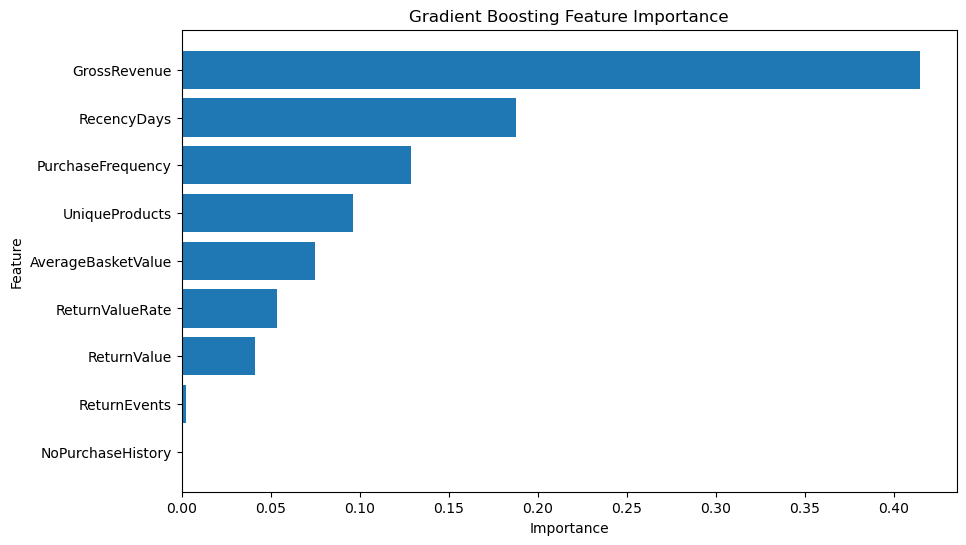

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [27]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, gb_prob)

print(f"Gradient Boosting Brier Score: {brier:.4f}")

Gradient Boosting Brier Score: 0.2131


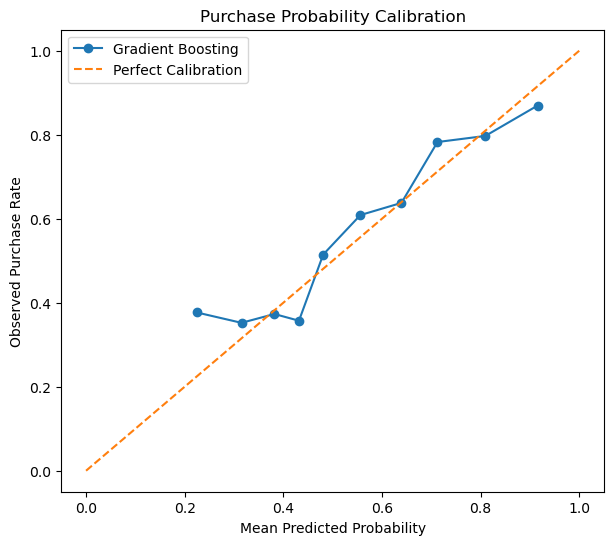

In [28]:
prob_true, prob_pred = calibration_curve(
    y_test,
    gb_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Purchase Rate")
plt.title("Purchase Probability Calibration")
plt.legend()
plt.show()

In [29]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_gb = CalibratedClassifierCV(
    gb_model,
    method="sigmoid",
    cv=5
)

calibrated_gb.fit(X_train, y_train)

calibrated_prob = calibrated_gb.predict_proba(X_test)[:, 1]
calibrated_pred = (calibrated_prob >= 0.5).astype(int)

In [30]:
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

calibrated_auc = roc_auc_score(y_test, calibrated_prob)
calibrated_brier = brier_score_loss(y_test, calibrated_prob)

calibrated_accuracy = accuracy_score(y_test, calibrated_pred)
calibrated_precision = precision_score(y_test, calibrated_pred)
calibrated_recall = recall_score(y_test, calibrated_pred)
calibrated_f1 = f1_score(y_test, calibrated_pred)

print("Calibrated Gradient Boosting")
print("-" * 40)
print(f"Accuracy : {calibrated_accuracy:.4f}")
print(f"Precision: {calibrated_precision:.4f}")
print(f"Recall   : {calibrated_recall:.4f}")
print(f"F1 Score : {calibrated_f1:.4f}")
print(f"ROC-AUC  : {calibrated_auc:.4f}")
print(f"Brier    : {calibrated_brier:.4f}")

Calibrated Gradient Boosting
----------------------------------------
Accuracy : 0.6768
Precision: 0.7270
Recall   : 0.6880
F1 Score : 0.7070
ROC-AUC  : 0.7197
Brier    : 0.2113


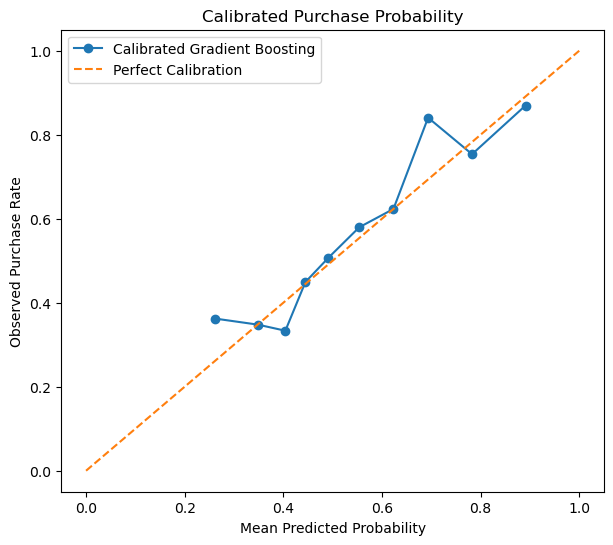

In [31]:
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    calibrated_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="Calibrated Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Purchase Rate")
plt.title("Calibrated Purchase Probability")
plt.legend()
plt.show()

In [33]:
print(model_df.columns.tolist())

['UserID', 'FuturePurchaseCount', 'PurchaseInFuture', 'PurchaseFrequency', 'GrossRevenue', 'UniqueProducts', 'LastPurchaseDate', 'AverageBasketValue', 'RecencyDays', 'ReturnEvents', 'ReturnValue', 'ReturnValueRate', 'NoPurchaseHistory']


In [34]:
print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'df', 'max_date', 'cutoff_date', 'historical_df', 'future_df', 'future_purchases', 'customer_base', 'historical_purchases', 'historical_returns', 'purchase_features', 'return_features', 'model_df', 'purchase_feature_cols', 'feature_cols', 'X', 'y', 'train_test_split', 'X_train', 'X_test', 'y_train', 'y_test', 'Pipeline', 'StandardScaler', 'LogisticRegression', 'logistic_model', 'y_pred', 'y_prob', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score', 'confusion_matrix', 'classification_report', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'RandomForestClassifier', 'rf_model', 'rf_pred', 'rf_prob', 'rf_accuracy', 'rf_precision', 'rf_recall', 'rf_f1', 'rf_roc_auc', 'GradientBoostingClassifier', 'gb_model', 'gb_pred', 'gb_prob', 'gb_accuracy', 'gb_precision', 'gb_recall', 'gb_f1', 'gb_roc_auc', 'feature_importance', 'plt', 'calibration_curve', 'brier_score_loss', 'brier', 'prob_true', 'prob

In [35]:
print(historical_purchases.columns.tolist())
print(historical_purchases.shape)
print(historical_purchases.head())

['EventID', 'EventType', 'ProductID', 'ProductName', 'Quantity', 'EventDateTime', 'UnitPrice', 'UserID', 'LineValue']
(253565, 9)
  EventID  EventType ProductID                    ProductName  Quantity  \
0  612890  Purchased     97393  DIWALI LANTERN WITH CARDBOARD        32   
1  612890  Purchased    91668P        FLOWER POTS WITH FLOWER        32   
2  612890  Purchased    91668W             RED COLORED LIGHTS        32   
3  612890  Purchased     34386                    PHOTO FRAME        68   
4  612890  Purchased     33577                      FUNNY HAT        44   

        EventDateTime  UnitPrice  UserID  LineValue  
0 2019-12-01 07:45:00     624.80   25430    19993.6  
1 2019-12-01 07:45:00     607.40   25430    19436.8  
2 2019-12-01 07:45:00     607.40   25430    19436.8  
3 2019-12-01 07:45:00     197.85   25430    13453.8  
4 2019-12-01 07:45:00     123.90   25430     5451.6  


In [36]:
# Aggregate purchased line items into transaction/basket level
historical_baskets = (
    historical_purchases
    .groupby(["EventID", "UserID", "EventDateTime"], as_index=False)
    .agg(
        BasketValue=("LineValue", "sum"),
        NumberOfLines=("ProductID", "count"),
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("ProductID", "nunique")
    )
)

print("Historical baskets:", len(historical_baskets))
print("Unique customers:", historical_baskets["UserID"].nunique())

print("\nBasket value summary:")
print(historical_baskets["BasketValue"].describe())

Historical baskets: 12518
Unique customers: 3379

Basket value summary:
count    1.251800e+04
mean     1.175015e+05
std      1.982229e+05
min      2.272500e+02
25%      4.868007e+04
50%      8.676835e+04
75%      1.400488e+05
max      1.048272e+07
Name: BasketValue, dtype: float64


In [37]:
historical_baskets.head()

,EventID,UserID,EventDateTime,BasketValue,NumberOfLines,TotalQuantity,UniqueProducts
0,612890,25430,2019-12-01 07:45:00,106341.00,8,326,8
1,612891,25430,2019-12-01 07:46:00,33075.60,4,140,4
2,612892,25423,2019-12-01 09:06:00,154245.36,19,493,19
3,612893,27707,2019-12-01 09:08:00,112372.00,23,445,23
4,612894,30447,2019-12-01 09:24:00,294014.78,17,1166,17


In [38]:
print("Historical baskets:", len(historical_baskets))
print("Unique customers:", historical_baskets["UserID"].nunique())

print("\nBasket Value Summary:")
print(historical_baskets["BasketValue"].describe())

Historical baskets: 12518
Unique customers: 3379

Basket Value Summary:
count    1.251800e+04
mean     1.175015e+05
std      1.982229e+05
min      2.272500e+02
25%      4.868007e+04
50%      8.676835e+04
75%      1.400488e+05
max      1.048272e+07
Name: BasketValue, dtype: float64


In [39]:
basket_target = (
    historical_baskets
    .groupby("UserID")
    .agg(
        TargetBasketValue=("BasketValue", "mean"),
        HistoricalBaskets=("EventID", "nunique")
    )
    .reset_index()
)

print("Customers:", len(basket_target))
print(basket_target["TargetBasketValue"].describe())

Customers: 3379
count    3.379000e+03
mean     1.121406e+05
std      2.299877e+05
min      2.272500e+02
25%      5.697032e+04
50%      8.929191e+04
75%      1.288180e+05
max      1.048272e+07
Name: TargetBasketValue, dtype: float64


In [40]:
basket_model_df = model_df.merge(
    basket_target,
    on="UserID",
    how="inner"
)

print("Basket model rows:", len(basket_model_df))
print(basket_model_df.head())

Basket model rows: 3379
   UserID  FuturePurchaseCount  PurchaseInFuture  PurchaseFrequency  \
0   25430                  0.0                 0                6.0   
1   25423                140.0                 1               24.0   
2   27707                 17.0                 1                1.0   
3   30447                 60.0                 1               78.0   
4   25027                153.0                 1               16.0   

   GrossRevenue  UniqueProducts    LastPurchaseDate  AverageBasketValue  \
0     471636.60            33.0 2020-01-29 11:42:00        78606.100000   
1    2578722.68            83.0 2020-09-03 14:28:00       107446.778333   
2     112372.00            23.0 2019-12-01 09:08:00       112372.000000   
3   27999526.39           268.0 2020-08-31 09:31:00       358968.287051   
4    2249432.06           155.0 2020-09-09 12:19:00       140589.503750   

   RecencyDays  ReturnEvents  ReturnValue  ReturnValueRate  NoPurchaseHistory  \
0   225.346528   

In [41]:
basket_features = [
    "PurchaseFrequency",
    "GrossRevenue",
    "UniqueProducts",
    "RecencyDays",
    "ReturnEvents",
    "ReturnValue",
    "ReturnValueRate",
    "HistoricalBaskets"
]

X_basket = basket_model_df[basket_features].copy()
y_basket = basket_model_df["TargetBasketValue"].copy()

print("X_basket shape:", X_basket.shape)
print("y_basket shape:", y_basket.shape)

print("\nMissing values:")
print(X_basket.isna().sum())

X_basket shape: (3379, 8)
y_basket shape: (3379,)

Missing values:
PurchaseFrequency    0
GrossRevenue         0
UniqueProducts       0
RecencyDays          0
ReturnEvents         0
ReturnValue          0
ReturnValueRate      0
HistoricalBaskets    0
dtype: int64


In [42]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_basket,
    y_basket,
    test_size=0.20,
    random_state=42
)

print("Training:", Xb_train.shape)
print("Test:", Xb_test.shape)

Training: (2703, 8)
Test: (676, 8)


In [43]:
from sklearn.ensemble import RandomForestRegressor

# Log-transform the basket value target
yb_train_log = np.log1p(yb_train)

basket_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5
)

basket_rf.fit(Xb_train, yb_train_log)

# Predict in log space
yb_pred_log = basket_rf.predict(Xb_test)

# Convert back to original currency/value scale
yb_pred = np.expm1(yb_pred_log)

print("Basket Value Random Forest trained successfully.")

Basket Value Random Forest trained successfully.


In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(yb_test, yb_pred)
rmse = np.sqrt(mean_squared_error(yb_test, yb_pred))
r2 = r2_score(yb_test, yb_pred)

print("Basket Value Model Performance")
print("-" * 40)
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

Basket Value Model Performance
----------------------------------------
MAE : 5,095.44
RMSE: 41,957.73
R²  : 0.7838


In [45]:
model_df["PurchaseProbability"] = calibrated_gb.predict_proba(
    model_df[feature_cols]
)[:, 1]

In [47]:
# Add historical basket count to the main customer dataframe
model_df = model_df.merge(
    basket_target[["UserID", "HistoricalBaskets"]],
    on="UserID",
    how="left"
)

model_df["HistoricalBaskets"] = (
    model_df["HistoricalBaskets"].fillna(0)
)

print(model_df["HistoricalBaskets"].describe())

count    3449.000000
mean        3.622789
std         6.194411
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       122.000000
Name: HistoricalBaskets, dtype: float64


In [48]:
basket_input_all = model_df[
    model_df["PurchaseFrequency"] > 0
][basket_features].copy()

basket_predictions_all = basket_rf.predict(basket_input_all)

model_df.loc[
    model_df["PurchaseFrequency"] > 0,
    "ExpectedBasketValue"
] = np.expm1(basket_predictions_all)

model_df["ExpectedBasketValue"] = (
    model_df["ExpectedBasketValue"].fillna(0)
)

In [49]:
model_df["ExpectedRevenue"] = (
    model_df["PurchaseProbability"]
    * model_df["ExpectedBasketValue"]
)

In [50]:
print(
    model_df[
        [
            "UserID",
            "PurchaseProbability",
            "ExpectedBasketValue",
            "ExpectedRevenue"
        ]
    ].head(10)
)

print("\nExpected Revenue Summary:")
print(model_df["ExpectedRevenue"].describe())

   UserID  PurchaseProbability  ExpectedBasketValue  ExpectedRevenue
0   25430             0.263853         79575.254249     20996.172264
1   25423             0.935803        103773.563429     97111.657982
2   27707             0.224267        112346.896659     25195.712604
3   30447             0.796543        236792.305677    188615.271368
4   25027             0.936571        144615.947681    135443.039981
5   30432             0.882380        125817.788379    111019.082267
6   25980             0.528640         97427.670162     51504.135194
7   26455             0.924578         76028.490790     70294.258779
8   24981             0.145174        135313.283849     19643.915800
9   29864             0.854168         91895.277910     78493.965734

Expected Revenue Summary:
count      3449.000000
mean      62656.945666
std       53700.141491
min           0.000000
25%       25406.538958
50%       48589.066470
75%       83833.238473
max      538376.541147
Name: ExpectedRevenue, dtype: 

In [51]:
print(
    model_df["ExpectedRevenue"].quantile(
        [0.50, 0.75, 0.80, 0.90, 0.95, 0.99]
    )
)

0.50     48589.066470
0.75     83833.238473
0.80     95366.914891
0.90    133914.109897
0.95    166065.402930
0.99    249790.758983
Name: ExpectedRevenue, dtype: float64


In [52]:
high_threshold = model_df["ExpectedRevenue"].quantile(0.90)
medium_threshold = model_df["ExpectedRevenue"].quantile(0.75)

model_df["RevenueTargetTier"] = np.select(
    [
        model_df["ExpectedRevenue"] >= high_threshold,
        model_df["ExpectedRevenue"] >= medium_threshold
    ],
    [
        "High Value",
        "Medium Value"
    ],
    default="Standard Value"
)

print("High threshold:", high_threshold)
print("Medium threshold:", medium_threshold)

print("\nTarget Tier Distribution:")
print(model_df["RevenueTargetTier"].value_counts())

print("\nExpected Revenue by Tier:")
print(
    model_df.groupby("RevenueTargetTier")["ExpectedRevenue"]
    .agg(["count", "mean", "sum"])
    .sort_values("mean", ascending=False)
)

High threshold: 133914.10989651433
Medium threshold: 83833.2384730189

Target Tier Distribution:
RevenueTargetTier
Standard Value    2586
Medium Value       518
High Value         345
Name: count, dtype: int64

Expected Revenue by Tier:
                   count           mean           sum
RevenueTargetTier                                    
High Value           345  183025.249212  6.314371e+07
Medium Value         518  104318.571719  5.403702e+07
Standard Value      2586   38253.315729  9.892307e+07


In [56]:
print(model_df[
    [
        "UserID",
        "GrossRevenue",
        "RecencyDays",
        "ReturnValueRate"
    ]
].head())

   UserID  GrossRevenue  RecencyDays  ReturnValueRate
0   25430     471636.60   225.346528         0.000000
1   25423    2578722.68     7.231250         0.036842
2   27707     112372.00   284.453472         0.000000
3   30447   27999526.39    10.437500         0.109459
4   25027    2249432.06     1.320833         0.007765


In [59]:
# Stage 1 thresholds
high_value_threshold = 654811.84
active_threshold = 90
return_risk_threshold = 0.05

In [60]:
def assign_segment(row):
    
    # Return risk takes priority because it represents a direct
    # revenue leakage concern.
    if row["ReturnValueRate"] >= return_risk_threshold:
        return "Return Risk"
    
    # High-value customers who are recently active
    elif (
        row["GrossRevenue"] >= high_value_threshold
        and row["RecencyDays"] <= active_threshold
    ):
        return "Protect & Grow"
    
    # High-value customers who have not purchased recently
    elif (
        row["GrossRevenue"] >= high_value_threshold
        and row["RecencyDays"] > active_threshold
    ):
        return "Win Back"
    
    # Lower-value but recently active customers
    elif row["RecencyDays"] <= active_threshold:
        return "Upsell"
    
    # Lower-value and inactive customers
    else:
        return "Monitor"


model_df["BehavioralSegment"] = model_df.apply(
    assign_segment,
    axis=1
)

print(model_df["BehavioralSegment"].value_counts())

BehavioralSegment
Upsell            1327
Monitor           1255
Protect & Grow     416
Return Risk        410
Win Back            41
Name: count, dtype: int64


In [61]:
segment_targeting = (
    model_df
    .groupby(["BehavioralSegment", "RevenueTargetTier"])
    .agg(
        CustomerCount=("UserID", "nunique"),
        TotalExpectedRevenue=("ExpectedRevenue", "sum"),
        AverageExpectedRevenue=("ExpectedRevenue", "mean"),
        AveragePurchaseProbability=("PurchaseProbability", "mean"),
        AverageExpectedBasketValue=("ExpectedBasketValue", "mean")
    )
    .reset_index()
)

print(segment_targeting)

   BehavioralSegment RevenueTargetTier  CustomerCount  TotalExpectedRevenue  \
0            Monitor        High Value             58          9.602547e+06   
1            Monitor      Medium Value             95          9.751854e+06   
2            Monitor    Standard Value           1102          3.723181e+07   
3     Protect & Grow        High Value            162          3.070670e+07   
4     Protect & Grow      Medium Value            185          1.955243e+07   
5     Protect & Grow    Standard Value             69          4.703655e+06   
6        Return Risk        High Value             24          4.168214e+06   
7        Return Risk      Medium Value             59          6.219168e+06   
8        Return Risk    Standard Value            327          1.269147e+07   
9             Upsell        High Value             76          1.312821e+07   
10            Upsell      Medium Value            170          1.754201e+07   
11            Upsell    Standard Value           108

In [62]:
segment_summary = (
    model_df
    .groupby("BehavioralSegment")
    .agg(
        CustomerCount=("UserID", "nunique"),
        TotalExpectedRevenue=("ExpectedRevenue", "sum"),
        AverageExpectedRevenue=("ExpectedRevenue", "mean"),
        AveragePurchaseProbability=("PurchaseProbability", "mean"),
        AverageExpectedBasketValue=("ExpectedBasketValue", "mean")
    )
    .sort_values("TotalExpectedRevenue", ascending=False)
)

print(segment_summary)

                   CustomerCount  TotalExpectedRevenue  \
BehavioralSegment                                        
Upsell                      1327          7.456696e+07   
Monitor                     1255          5.658621e+07   
Protect & Grow               416          5.496279e+07   
Return Risk                  410          2.307885e+07   
Win Back                      41          6.908993e+06   

                   AverageExpectedRevenue  AveragePurchaseProbability  \
BehavioralSegment                                                       
Upsell                       56192.131375                    0.587378   
Monitor                      45088.612315                    0.444547   
Protect & Grow              132122.096324                    0.861612   
Return Risk                  56289.887400                    0.546855   
Win Back                    168512.022150                    0.574993   

                   AverageExpectedBasketValue  
BehavioralSegment                

In [63]:
final_targeting = model_df[
    [
        "UserID",
        "BehavioralSegment",
        "PurchaseProbability",
        "ExpectedBasketValue",
        "ExpectedRevenue",
        "RevenueTargetTier"
    ]
].copy()

final_targeting = final_targeting.sort_values(
    "ExpectedRevenue",
    ascending=False
).reset_index(drop=True)

print(final_targeting.head(20))

    UserID BehavioralSegment  PurchaseProbability  ExpectedBasketValue  \
0    24884          Win Back             0.710644        757589.465962   
1    24822    Protect & Grow             0.672556        746867.885179   
2    28417          Win Back             0.513974        771193.412401   
3    28168          Win Back             0.674848        573972.529978   
4    26588    Protect & Grow             0.658035        578261.387242   
5    25685    Protect & Grow             0.839481        432533.873544   
6    27496    Protect & Grow             0.556251        646429.131410   
7    25082    Protect & Grow             0.420691        848415.300345   
8    26394    Protect & Grow             0.841949        412292.908558   
9    26622    Protect & Grow             0.745314        464389.348791   
10   28131            Upsell             0.654696        526520.288472   
11   27641    Protect & Grow             0.880978        389941.549251   
12   29452    Protect & Grow          

In [64]:
print("\nFinal targeting rows:", len(final_targeting))
print("\nTarget tier distribution:")
print(final_targeting["RevenueTargetTier"].value_counts())

print("\nTop 10 customers:")
print(final_targeting.head(10))


Final targeting rows: 3449

Target tier distribution:
RevenueTargetTier
Standard Value    2586
Medium Value       518
High Value         345
Name: count, dtype: int64

Top 10 customers:
   UserID BehavioralSegment  PurchaseProbability  ExpectedBasketValue  \
0   24884          Win Back             0.710644        757589.465962   
1   24822    Protect & Grow             0.672556        746867.885179   
2   28417          Win Back             0.513974        771193.412401   
3   28168          Win Back             0.674848        573972.529978   
4   26588    Protect & Grow             0.658035        578261.387242   
5   25685    Protect & Grow             0.839481        432533.873544   
6   27496    Protect & Grow             0.556251        646429.131410   
7   25082    Protect & Grow             0.420691        848415.300345   
8   26394    Protect & Grow             0.841949        412292.908558   
9   26622    Protect & Grow             0.745314        464389.348791   

   Expect

In [65]:
print("Final targeting shape:", final_targeting.shape)

print("\nMissing values:")
print(final_targeting.isna().sum())

print("\nNegative Expected Revenue:",
      (final_targeting["ExpectedRevenue"] < 0).sum())

print("\nNegative Expected Basket Value:",
      (final_targeting["ExpectedBasketValue"] < 0).sum())

print("\nExpected Revenue total:",
      final_targeting["ExpectedRevenue"].sum())

print("\nTier totals:")
print(
    final_targeting
    .groupby("RevenueTargetTier")["ExpectedRevenue"]
    .agg(["count", "sum"])
)

Final targeting shape: (3449, 6)

Missing values:
UserID                 0
BehavioralSegment      0
PurchaseProbability    0
ExpectedBasketValue    0
ExpectedRevenue        0
RevenueTargetTier      0
dtype: int64

Negative Expected Revenue: 0

Negative Expected Basket Value: 0

Expected Revenue total: 216103805.60347638

Tier totals:
                   count           sum
RevenueTargetTier                     
High Value           345  6.314371e+07
Medium Value         518  5.403702e+07
Standard Value      2586  9.892307e+07


In [66]:
stage3_tier_summary = (
    final_targeting
    .groupby("RevenueTargetTier")
    .agg(
        CustomerCount=("UserID", "nunique"),
        TotalExpectedRevenue=("ExpectedRevenue", "sum"),
        AverageExpectedRevenue=("ExpectedRevenue", "mean"),
        AveragePurchaseProbability=("PurchaseProbability", "mean"),
        AverageExpectedBasketValue=("ExpectedBasketValue", "mean")
    )
    .reset_index()
)

stage3_tier_summary["CustomerShare"] = (
    stage3_tier_summary["CustomerCount"]
    / stage3_tier_summary["CustomerCount"].sum()
)

stage3_tier_summary["ExpectedRevenueShare"] = (
    stage3_tier_summary["TotalExpectedRevenue"]
    / stage3_tier_summary["TotalExpectedRevenue"].sum()
)

print(stage3_tier_summary)

  RevenueTargetTier  CustomerCount  TotalExpectedRevenue  \
0        High Value            345          6.314371e+07   
1      Medium Value            518          5.403702e+07   
2    Standard Value           2586          9.892307e+07   

   AverageExpectedRevenue  AveragePurchaseProbability  \
0           183025.249212                    0.730684   
1           104318.571719                    0.749401   
2            38253.315729                    0.503982   

   AverageExpectedBasketValue  CustomerShare  ExpectedRevenueShare  
0               266597.404449       0.100029              0.292192  
1               145996.138279       0.150188              0.250051  
2                74372.652587       0.749783              0.457757  


In [67]:
stage3_matrix = (
    model_df
    .groupby(["BehavioralSegment", "RevenueTargetTier"])
    .agg(
        CustomerCount=("UserID", "nunique"),
        ExpectedRevenue=("ExpectedRevenue", "sum")
    )
    .reset_index()
)

print(stage3_matrix)

   BehavioralSegment RevenueTargetTier  CustomerCount  ExpectedRevenue
0            Monitor        High Value             58     9.602547e+06
1            Monitor      Medium Value             95     9.751854e+06
2            Monitor    Standard Value           1102     3.723181e+07
3     Protect & Grow        High Value            162     3.070670e+07
4     Protect & Grow      Medium Value            185     1.955243e+07
5     Protect & Grow    Standard Value             69     4.703655e+06
6        Return Risk        High Value             24     4.168214e+06
7        Return Risk      Medium Value             59     6.219168e+06
8        Return Risk    Standard Value            327     1.269147e+07
9             Upsell        High Value             76     1.312821e+07
10            Upsell      Medium Value            170     1.754201e+07
11            Upsell    Standard Value           1081     4.389674e+07
12          Win Back        High Value             25     5.538038e+06
13    

In [68]:
customer_matrix = pd.pivot_table(
    stage3_matrix,
    index="BehavioralSegment",
    columns="RevenueTargetTier",
    values="CustomerCount",
    fill_value=0
)

print(customer_matrix)

RevenueTargetTier  High Value  Medium Value  Standard Value
BehavioralSegment                                          
Monitor                  58.0          95.0          1102.0
Protect & Grow          162.0         185.0            69.0
Return Risk              24.0          59.0           327.0
Upsell                   76.0         170.0          1081.0
Win Back                 25.0           9.0             7.0


In [69]:
revenue_matrix = pd.pivot_table(
    stage3_matrix,
    index="BehavioralSegment",
    columns="RevenueTargetTier",
    values="ExpectedRevenue",
    fill_value=0
)

print(revenue_matrix)

RevenueTargetTier    High Value  Medium Value  Standard Value
BehavioralSegment                                            
Monitor            9.602547e+06  9.751854e+06    3.723181e+07
Protect & Grow     3.070670e+07  1.955243e+07    4.703655e+06
Return Risk        4.168214e+06  6.219168e+06    1.269147e+07
Upsell             1.312821e+07  1.754201e+07    4.389674e+07
Win Back           5.538038e+06  9.715591e+05    3.993958e+05


In [70]:
def assign_targeting_group(row):

    if row["RevenueTargetTier"] == "High Value":
        return "High Revenue Opportunity"

    elif (
        row["BehavioralSegment"] == "Return Risk"
        and row["RevenueTargetTier"] == "Medium Value"
    ):
        return "Return Risk - Medium Value"

    elif (
        row["BehavioralSegment"] == "Win Back"
        and row["RevenueTargetTier"] == "Medium Value"
    ):
        return "Win Back - Medium Value"

    elif row["RevenueTargetTier"] == "Medium Value":
        return "Medium Revenue Opportunity"

    else:
        return "Standard Opportunity"


model_df["TargetingGroup"] = model_df.apply(
    assign_targeting_group,
    axis=1
)

print(model_df["TargetingGroup"].value_counts())

TargetingGroup
Standard Opportunity          2586
Medium Revenue Opportunity     450
High Revenue Opportunity       345
Return Risk - Medium Value      59
Win Back - Medium Value          9
Name: count, dtype: int64


In [71]:
stage3_business_summary = (
    model_df
    .groupby("TargetingGroup")
    .agg(
        CustomerCount=("UserID", "nunique"),
        TotalExpectedRevenue=("ExpectedRevenue", "sum"),
        AverageExpectedRevenue=("ExpectedRevenue", "mean"),
        AveragePurchaseProbability=("PurchaseProbability", "mean"),
        AverageExpectedBasketValue=("ExpectedBasketValue", "mean")
    )
    .reset_index()
    .sort_values("TotalExpectedRevenue", ascending=False)
)

print(stage3_business_summary)

               TargetingGroup  CustomerCount  TotalExpectedRevenue  \
3        Standard Opportunity           2586          9.892307e+07   
0    High Revenue Opportunity            345          6.314371e+07   
1  Medium Revenue Opportunity            450          4.684629e+07   
2  Return Risk - Medium Value             59          6.219168e+06   
4     Win Back - Medium Value              9          9.715591e+05   

   AverageExpectedRevenue  AveragePurchaseProbability  \
3            38253.315729                    0.503982   
0           183025.249212                    0.730684   
1           104102.873365                    0.758675   
2           105409.627478                    0.694164   
4           107951.012770                    0.647852   

   AverageExpectedBasketValue  
3                74372.652587  
0               266597.404449  
1               142829.013041  
2               165001.664252  
4               179760.618781  


In [72]:
stage3_business_summary["CustomerShare"] = (
    stage3_business_summary["CustomerCount"]
    / stage3_business_summary["CustomerCount"].sum()
)

stage3_business_summary["ExpectedRevenueShare"] = (
    stage3_business_summary["TotalExpectedRevenue"]
    / stage3_business_summary["TotalExpectedRevenue"].sum()
)

print(stage3_business_summary)

               TargetingGroup  CustomerCount  TotalExpectedRevenue  \
3        Standard Opportunity           2586          9.892307e+07   
0    High Revenue Opportunity            345          6.314371e+07   
1  Medium Revenue Opportunity            450          4.684629e+07   
2  Return Risk - Medium Value             59          6.219168e+06   
4     Win Back - Medium Value              9          9.715591e+05   

   AverageExpectedRevenue  AveragePurchaseProbability  \
3            38253.315729                    0.503982   
0           183025.249212                    0.730684   
1           104102.873365                    0.758675   
2           105409.627478                    0.694164   
4           107951.012770                    0.647852   

   AverageExpectedBasketValue  CustomerShare  ExpectedRevenueShare  
3                74372.652587       0.749783              0.457757  
0               266597.404449       0.100029              0.292192  
1               142829.013041